In [4]:
import tensorflow as tf
import numpy as np
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


In [6]:
def custom_loss(y_true, y_pred):
    # Define your custom loss function here
    loss = tf.reduce_mean(tf.square(y_true - y_pred))
    return loss

def call(self, inputs):
    z_mean, z_log_var, z = self.encoder(inputs)
    reconstructed = self.decoder(z)
    return reconstructed


latent_dim=5
dim=10

# Generate uniform distributed data
x_train = np.random.uniform(low=0, high=1, size=(60000, dim))
x_test = np.random.uniform(low=0, high=1, size=(10000, dim))

# Define the encoder
encoder_inputs = tf.keras.Input(shape=(dim,))
x = tf.keras.layers.Dense(8, activation="relu")(encoder_inputs)
x = tf.keras.layers.Dense(4, activation="relu")(x)
encoder_outputs = tf.keras.layers.Dense(latent_dim, activation="relu")(x)
encoder = tf.keras.Model(encoder_inputs, encoder_outputs, name="encoder")

# Define the decoder
decoder_inputs = tf.keras.Input(shape=(latent_dim,))
x = tf.keras.layers.Dense(4, activation="relu")(decoder_inputs)
x = tf.keras.layers.Dense(8, activation="relu")(x)
decoder_outputs = tf.keras.layers.Dense(dim, activation="relu")(x)
decoder = tf.keras.Model(decoder_inputs, decoder_outputs, name="decoder")

# Define the autoencoder
autoencoder_inputs = tf.keras.Input(shape=(dim,))
encoded = encoder(autoencoder_inputs)
decoded = decoder(encoded)
autoencoder = tf.keras.Model(autoencoder_inputs, decoded, name="autoencoder")

# Compile the model
autoencoder.compile(optimizer="adam", loss=custom_loss)

# Train the model
autoencoder.fit(x_train, x_train, epochs=10*2, batch_size=128*4, shuffle=True, validation_data=(x_test, x_test))


Epoch 1/20
118/118 [==============================] - 0s 4ms/step - loss: 0.2596 - val_loss: 0.2331
Epoch 2/20
118/118 [==============================] - 0s 3ms/step - loss: 0.2306 - val_loss: 0.2289
Epoch 3/20
118/118 [==============================] - 0s 3ms/step - loss: 0.2275 - val_loss: 0.2268
Epoch 4/20
118/118 [==============================] - 0s 3ms/step - loss: 0.2259 - val_loss: 0.2258
Epoch 5/20
118/118 [==============================] - 0s 3ms/step - loss: 0.2226 - val_loss: 0.2012
Epoch 6/20
118/118 [==============================] - 0s 3ms/step - loss: 0.1779 - val_loss: 0.1750
Epoch 7/20
118/118 [==============================] - 0s 3ms/step - loss: 0.1749 - val_loss: 0.1749
Epoch 8/20
118/118 [==============================] - 0s 3ms/step - loss: 0.1749 - val_loss: 0.1749
Epoch 9/20
118/118 [==============================] - 0s 3ms/step - loss: 0.1749 - val_loss: 0.1749
Epoch 10/20
118/118 [==============================] - 0s 3ms/step - loss: 0.1749 - val_loss: 0.1749

In [18]:

# Generate reconstructed images
#reconstructed_data = autoencoder.predict(x_test)

# Plot some of the original and reconstructed images
#n = 10  # Number of images to plot
#plt.figure(figsize=(12, 1))
#for i in range(n):
    # Plot original image
#    ax = plt.subplot(2, n, i + 1)
#    plt.imshow(x_test[i].squeeze())
#    plt.title("Original")
#    plt.gray()
#    ax.get_xaxis().set_visible(False)
#    ax.get_yaxis().set_visible(False)

    # Plot reconstructed image
#    ax = plt.subplot(2, n, i + n + 1)
#    plt.imshow(reconstructed_images[i].squeeze())
#    plt.title("Reconstructed")
#    plt.gray()
#    ax.get_xaxis().set_visible(False)
#    ax.get_yaxis().set_visible(False)
#plt.show()


In [19]:
test_loss = autoencoder.evaluate(x_test, x_test)
print(f'Test loss: {test_loss:.4f}')

313/313 [==============================] - 0s 1ms/step - loss: 0.1749
Test loss: 0.1749


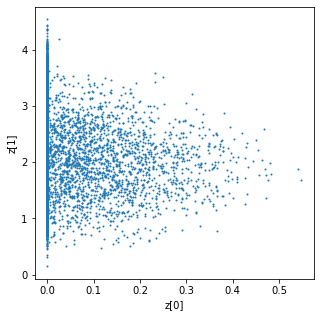

In [20]:
import numpy as np
import matplotlib.pyplot as plt
#import matplotlib
#matplotlib.use('TkAgg')

# Encode the test dataset to get the latent vectors
encoded_imgs = encoder.predict(x_test)

# Get the labels for each image
#labels = y_test

# Plot the latent vectors in 2D or 3D space using a scatter plot
fig = plt.figure(figsize=(5, 5))
#if latent_dim == 2:
plt.scatter(encoded_imgs[:, 1], encoded_imgs[:, 3], cmap='viridis', s=1)
plt.xlabel("z[0]")
plt.ylabel("z[1]")
#elif latent_dim == 3:
#    ax = fig.add_subplot(111, projection='3d')
#    ax.scatter(encoded_imgs[:, 0], encoded_imgs[:, 1], encoded_imgs[:, 2], c=labels, cmap='viridis')
#    ax.set_xlabel("z[0]")
#    ax.set_ylabel("z[1]")
#    ax.set_zlabel("z[2]")
#    plt.colorbar()
plt.show()


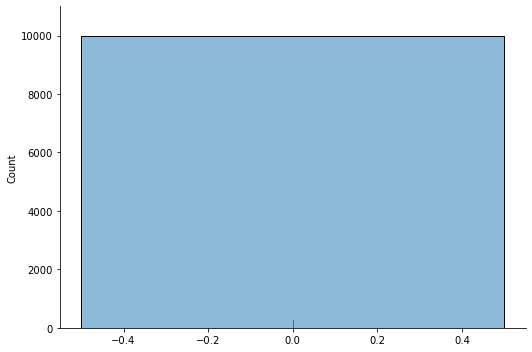

In [21]:


# Generate some random data
data = encoded_imgs[:, 2]
#np.random.normal(size=1000)

# Plot the kernel density estimate and the histogram
sns.displot(data, kde=True, rug=True, height=5, aspect=1.5)

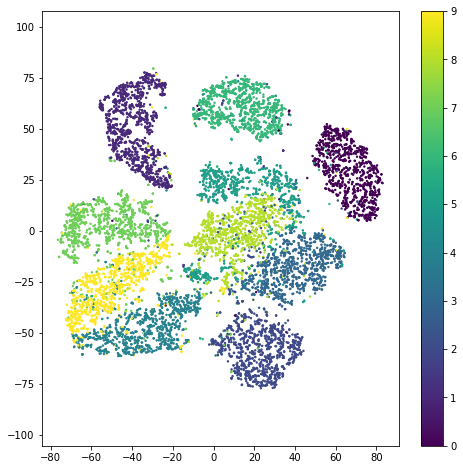

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Encode the test dataset to get the latent vectors
encoded_imgs = encoder.predict(x_test)

# Get the labels for each image
labels = y_test

# Use t-SNE to project the latent vectors to 2D space
tsne = TSNE(n_components=2, random_state=42)
encoded_imgs_tsne = tsne.fit_transform(encoded_imgs)

# Plot the t-SNE projection
fig = plt.figure(figsize=(8, 8))
plt.scatter(encoded_imgs_tsne[:, 0], encoded_imgs_tsne[:, 1], c=labels, cmap='viridis', s=2)
plt.colorbar()
plt.axis('equal')
plt.show()
